# Module 10: Interactive Plots with Plotly

Every figure we have built so far is a static image: once rendered, the reader sees exactly what the code produced and nothing more. Plotly produces figures that live in the browser as interactive HTML, so the viewer can zoom, pan, hover over individual points to read their values, and toggle series on and off. This changes what you can show in a single figure and how you explore data before committing to a final visualization.

## Install and imports

Plotly is not part of the standard Colab environment and needs to be installed once per session.

In [1]:
#!pip install plotly --quiet

## Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 1. Plotly Express vs. Graph Objects

Plotly has two layers. `plotly.express` (imported as `px`) is the high-level layer: you pass a DataFrame and column names, and it produces a complete figure in one function call. It covers scatter plots, line plots, bar charts, histograms, 3D scatter, and more. `plotly.graph_objects` (imported as `go`) is the lower-level layer: you build a figure by constructing trace objects and adding them to a `go.Figure` one at a time. Graph objects give you precise control over every visual property and are the right choice when a figure needs custom hover templates, mixed trace types, or layout details that Express does not expose directly.

The two layers are not alternatives: an Express figure is a `go.Figure` under the hood, so you can always take an Express result and modify it with Graph Objects methods afterward.

In [3]:
# A minimal comparison: the same scatter plot via Express and Graph Objects
x_demo = np.linspace(0, 2 * np.pi, 60)
y_demo = np.sin(x_demo)

# Express version: one line
fig_px = px.scatter(x=x_demo, y=y_demo, title='Express: one line')
fig_px.show()

# Graph Objects version: explicit trace construction
fig_go = go.Figure()
fig_go.add_trace(go.Scatter(x=x_demo, y=y_demo, mode='markers', name='sin(x)'))
fig_go.update_layout(title='Graph Objects: explicit trace')
fig_go.show()

Both figures are interactive: try hovering over points to see their coordinates, clicking and dragging to zoom, and double-clicking to reset the view. The Express and Graph Objects figures behave identically from the viewer's perspective. The difference is entirely in how much you write to create them.

## Polymer dataset (from Module 09)

We rebuild the same synthetic polymer dataset used in Module 09 so this notebook runs independently.

In [4]:
rng = np.random.default_rng(seed=42)
n = 20

pp = pd.DataFrame({'polymer_type': 'PP', 'Mw': rng.normal(250_000, 40_000, n).clip(120_000, 400_000), 'dispersity': rng.normal(2.8, 0.4, n).clip(1.8, 4.2), 'Tg': rng.normal(-5, 4, n).clip(-18, 8), 'tensile_strength': rng.normal(32, 4, n).clip(22, 42), 'elongation': rng.normal(400, 80, n).clip(180, 700)})
pe = pd.DataFrame({'polymer_type': 'PE', 'Mw': rng.normal(180_000, 35_000, n).clip(80_000, 320_000), 'dispersity': rng.normal(3.5, 0.5, n).clip(2.0, 5.5), 'Tg': rng.normal(-120, 6, n).clip(-138, -102), 'tensile_strength': rng.normal(25, 5, n).clip(12, 38), 'elongation': rng.normal(600, 100, n).clip(300, 900)})
ps = pd.DataFrame({'polymer_type': 'PS', 'Mw': rng.normal(200_000, 30_000, n).clip(100_000, 320_000), 'dispersity': rng.normal(2.2, 0.3, n).clip(1.5, 3.2), 'Tg': rng.normal(100, 4, n).clip(88, 114), 'tensile_strength': rng.normal(45, 5, n).clip(32, 60), 'elongation': rng.normal(3.5, 0.8, n).clip(1.5, 6.5)})

polymer_df = pd.concat([pp, pe, ps], ignore_index=True)
polymer_df['Mw']               = polymer_df['Mw'].round(0).astype(int)
polymer_df['dispersity']       = polymer_df['dispersity'].round(2)
polymer_df['Tg']               = polymer_df['Tg'].round(1)
polymer_df['tensile_strength'] = polymer_df['tensile_strength'].round(1)
polymer_df['elongation']       = polymer_df['elongation'].round(1)

print(f'{len(polymer_df)} rows, columns: {list(polymer_df.columns)}')

60 rows, columns: ['polymer_type', 'Mw', 'dispersity', 'Tg', 'tensile_strength', 'elongation']


## 2. Basic 2D interactive scatter with `px.scatter`

The key interactive features of a Plotly scatter plot come for free: hover tooltips show the data values under the cursor, click-and-drag zooms into a region, double-click resets the view, and clicking a legend entry toggles that series on and off. The `hover_data` argument adds extra columns to the tooltip beyond the x and y values.

In [5]:
fig_scatter = px.scatter(
    polymer_df,
    x='Mw',
    y='tensile_strength',
    color='polymer_type',
    symbol='polymer_type',
    hover_data={'dispersity': True, 'Tg': True, 'elongation': True},
    color_discrete_map={'PP': '#4682b4', 'PE': '#b22222', 'PS': '#2e8b57'},
    labels={'Mw': 'Mw (g mol⁻¹)', 'tensile_strength': 'Tensile strength (MPa)','polymer_type': 'Polymer type'},
    title='Polymer dataset: Mw vs. tensile strength'
)

fig_scatter.update_traces(marker_size=5)
fig_scatter.update_layout(
    legend_title_text='Polymer type',
    font_family='Arial',
    hoverlabel_font_size=12
)

fig_scatter.show()

Hover over any point to see its Mw, tensile strength, dispersity, Tg, and elongation values. Click on a polymer type in the legend to hide it; click again to restore it. Try selecting a region with the box select tool (the dotted rectangle in the toolbar) to isolate a cluster. None of this requires any additional code: it is the default behavior of every Plotly figure.

## 3. Time-temperature superposition master curve

Time-temperature superposition (TTS) is a fundamental technique in polymer rheology. The storage modulus G' of a viscoelastic material is measured as a function of angular frequency at several temperatures. Because viscoelastic response is thermally activated, curves measured at different temperatures have the same shape but appear shifted along the frequency axis. A shift factor $a_T$ is applied to each curve to collapse them onto a single master curve at a reference temperature $T_{ref}$.

Interactivity is genuinely useful here in a way that a static plot cannot match: after shifting, data points from different original temperatures overlap completely, and there is no way to tell which temperature they came from without hovering. A static plot with a color legend helps, but a custom hover tooltip that shows both the shift factor and the original temperature gives the reader full traceability of every point.

In [6]:
# Measurement temperatures and reference temperature
temperatures = np.array([-40, -20, 0, 20, 40, 60])   # deg C
T_ref = 20.0                                           # deg C

# WLF shift factors: log10(aT) = -C1*(T - T_ref) / (C2 + T - T_ref)
# WLF constants typical for a polymer near Tg
C1, C2 = 8.86, 101.6

def wlf_log_aT(T, T_ref, C1, C2):
    delta_T = T - T_ref
    return -C1 * delta_T / (C2 + delta_T)

# Base frequency grid for each measurement (rad/s)
omega_base = np.logspace(-2, 3, 40)

# Synthetic G' model: a power-law rise with a plateau (simplified)
def Gprime_model(omega, T):
    """G' in Pa, with a slight temperature-dependent vertical shift."""
    G_plateau = 5e5                           # rubbery plateau modulus (Pa)
    n_slope = 0.55                            # slope in the terminal region
    # Vertical shift bT (approximate, set to 1 here for simplicity)
    return G_plateau * (omega ** n_slope) / (1 + (omega / 1e4) ** n_slope)

# Build a DataFrame with one row per (temperature, frequency) combination
rows = []
for T in temperatures:
    log_aT = wlf_log_aT(T, T_ref, C1, C2)
    aT = 10 ** log_aT
    for omega in omega_base:
        # Shifted frequency: multiply by aT to move curve to T_ref
        omega_shifted = omega * aT
        Gp = Gprime_model(omega_shifted, T)
        rows.append({
            'omega_shifted': omega_shifted,
            'Gprime': Gp,
            'temperature': T,
            'aT': round(aT, 4),
            'log_aT': round(log_aT, 3),
            'temp_label': f'{T} °C'
        })

tts_df = pd.DataFrame(rows)
print(f'TTS dataset: {len(tts_df)} points across {len(temperatures)} temperatures')

TTS dataset: 240 points across 6 temperatures


In [7]:
fig_tts = px.line(
    tts_df,
    x='omega_shifted',
    y='Gprime',
    color='temp_label',
    log_x=True,
    log_y=True,
    labels={
        'omega_shifted': 'ω·a<sub>T</sub> (rad s⁻¹)',
        'Gprime': "G' (Pa)",
        'temp_label': 'Temperature'
    },
    title=f"TTS master curve (T<sub>ref</sub> = {int(T_ref)} °C)",
    hover_data={'aT': True, 'log_aT': True, 'temperature': True, 'temp_label': False}
)

# Custom hover template: show temperature, aT and the original label clearly
fig_tts.update_traces(
    hovertemplate=(
        '<b>%{customdata[0]} °C</b><br>'
        'ω·a<sub>T</sub>: %{x:.3e} rad s⁻¹<br>'
        "G': %{y:.3e} Pa<br>"
        'a<sub>T</sub>: %{customdata[1]:.4f}<br>'
        'log(a<sub>T</sub>): %{customdata[2]:.3f}'
        '<extra></extra>'    # suppresses the default trace name box
    ),
    customdata=tts_df[['temperature', 'aT', 'log_aT']].values
)

fig_tts.update_layout(
    legend_title_text='Measurement temp.',
    font_family='Arial',
    hovermode='closest'
)

fig_tts.show()

In the overlapping region of the master curve, hover over any point to see which temperature it came from and what shift factor was applied. On a static plot, overlapping curves from adjacent temperatures are indistinguishable once shifted; here, every point carries its full provenance. The `<extra></extra>` tag in the hover template suppresses the secondary box that Plotly would otherwise add showing the trace name, which keeps the tooltip clean.

## 4. Interactive curve fit with `go.Scatter`

Graph Objects are the right choice when you need a figure composed of multiple trace types with different styling, or when you want to set hover templates independently for each trace. Here we reproduce the curve fitting example from Module 04: experimental data points and a fitted model curve on the same axes, built trace by trace.

In [8]:
from scipy.optimize import curve_fit

# Synthetic viscosity vs. shear rate data (power-law fluid)
rng_cf = np.random.default_rng(seed=3)
shear_rate = np.logspace(-1, 3, 22)         # s^-1
K, n_exp = 8.5, 0.42                        # true power-law parameters
eta_true = K * shear_rate ** (n_exp - 1)    # apparent viscosity (Pa.s)
eta_data = eta_true * rng_cf.lognormal(0, 0.08, len(shear_rate))  # add log-normal noise

def power_law(gamma_dot, K_fit, n_fit):
    return K_fit * gamma_dot ** (n_fit - 1)

popt, _ = curve_fit(power_law, shear_rate, eta_data, p0=[5.0, 0.5])
K_fit, n_fit = popt

shear_rate_fit = np.logspace(-1, 3, 200)
eta_fit = power_law(shear_rate_fit, K_fit, n_fit)

print(f'Fitted: K = {K_fit:.3f} Pa·sⁿ,  n = {n_fit:.3f}')

Fitted: K = 7.706 Pa·sⁿ,  n = 0.348


In [9]:
fig_cf = go.Figure()

# Experimental data: markers with a tooltip that shows both axes
fig_cf.add_trace(go.Scatter(
    x=shear_rate,
    y=eta_data,
    mode='markers',
    name='Experimental',
    marker=dict(color='steelblue', size=8, symbol='circle'),
    hovertemplate=(
        'γ̇: %{x:.2f} s⁻¹<br>'
        'η: %{y:.4f} Pa·s'
        '<extra>Data</extra>'
    )
))

# Fitted curve: line only, no markers
fig_cf.add_trace(go.Scatter(
    x=shear_rate_fit,
    y=eta_fit,
    mode='lines',
    name=f'Power law fit (K={K_fit:.2f}, n={n_fit:.3f})',
    line=dict(color='firebrick', width=2, dash='solid'),
    hovertemplate=(
        'γ̇: %{x:.2f} s⁻¹<br>'
        'η (fit): %{y:.4f} Pa·s'
        '<extra>Fit</extra>'
    )
))

fig_cf.update_layout(
    title='Viscosity vs. shear rate: power-law fit',
    xaxis=dict(title='Shear rate γ̇ (s⁻¹)', type='log'),
    yaxis=dict(title='Apparent viscosity η (Pa·s)', type='log'),
    legend=dict(x=0.02, y=0.05),
    font_family='Arial',
    hovermode='x unified'
)

fig_cf.show()

Using `go.Scatter` for each trace independently means the hover templates can be written separately for the data points and the fitted line. `hovermode='x unified'` shows both values (data and fit) in a single tooltip when the cursor is near a given x position, which makes it easy to see the residual at any shear rate. The `<extra>` tag sets the colored label that appears at the top of each tooltip entry.

## 5. Interactive 3D scatter: RAFT search space

The 3D scatter from Module 08 showed how Bayesian optimization rounds expanded the RAFT experimental search space. In a static Matplotlib figure, rotating the view required re-running the cell with a different `view_init` call. In Plotly, the viewer can rotate, zoom, and inspect individual points interactively. Hover labels restore the physical values of R/I ratio, M/R ratio, and reaction time, which were normalized before plotting and would otherwise be unreadable from the axes.

In [10]:
# Rebuild the RAFT dataset from Module 08
ri_lo, ri_hi     = 0.5,  10.0
mr_lo, mr_hi     = 15.0, 36.0
time_lo, time_hi = 0.1,  20.0

def log_norm(values, lo, hi):
    return (np.log(values) - np.log(lo)) / (np.log(hi) - np.log(lo))

ri_init   = np.array([0.6,  1.2,  2.5,  5.0,  9.0,  0.8,  3.5,  7.0,  1.8])
mr_init   = np.array([16.0, 20.0, 32.0, 18.0, 28.0, 35.0, 24.0, 16.5, 30.0])
time_init = np.array([0.2,  1.0,  5.0,  10.0, 18.0, 3.0,  0.5,  7.0,  14.0])

ri_r1   = np.array([1.0,  2.0,  4.0,  6.0,  8.0,  1.5,  3.0,  5.5,  7.5,  2.8])
mr_r1   = np.array([15.5, 17.0, 19.0, 22.0, 24.5, 16.0, 21.0, 23.0, 18.5, 20.5])
time_r1 = np.array([0.15, 0.4,  1.2,  2.5,  4.5,  0.8,  1.8,  3.2,  0.3,  2.0])

ri_r2   = np.array([1.2,  3.5,  6.0,  9.5,  2.0,  4.5,  7.0,  1.5,  5.0])
mr_r2   = np.array([26.0, 29.0, 32.0, 34.5, 27.5, 31.0, 35.5, 28.0, 33.0])
time_r2 = np.array([6.0,  9.0,  13.0, 18.5, 7.5,  11.0, 16.0, 8.5,  14.5])

def make_raft_df(ri, mr, time, round_label):
    return pd.DataFrame({
        'x': log_norm(ri, ri_lo, ri_hi),
        'y': log_norm(mr, mr_lo, mr_hi),
        'z': log_norm(time, time_lo, time_hi),
        'ri_phys':   ri,
        'mr_phys':   mr,
        'time_phys': time,
        'round':     round_label
    })

raft_df = pd.concat([
    make_raft_df(ri_init, mr_init, time_init, 'Initial'),
    make_raft_df(ri_r1,   mr_r1,   time_r1,   'Round 1'),
    make_raft_df(ri_r2,   mr_r2,   time_r2,   'Round 2'),
], ignore_index=True)

print(f'RAFT dataset: {len(raft_df)} experiments across 3 rounds')

RAFT dataset: 28 experiments across 3 rounds


In [11]:
fig_raft = px.scatter_3d(
    raft_df,
    x='x', y='y', z='z',
    color='round',
    symbol='round',
    color_discrete_map={'Initial': '#808080', 'Round 1': '#b22222', 'Round 2': '#4682b4'},
    opacity=0.85,
    custom_data=['ri_phys', 'mr_phys', 'time_phys', 'round'],
    labels={
        'x': 'R/I (log norm.)',
        'y': 'M/R (log norm.)',
        'z': 'Time (log norm.)',
        'round': 'Experiment round'
    },
    title='RAFT polymerization: Bayesian optimization search space'
)

# Custom hover to show physical (un-normalized) values
fig_raft.update_traces(
    marker_size=3,
    hovertemplate=(
        '<b>%{customdata[3]}</b><br>'
        'R/I ratio: %{customdata[0]:.2f}<br>'
        'M/R ratio: %{customdata[1]:.1f}<br>'
        'Time: %{customdata[2]:.2f} min'
        '<extra></extra>'
    )
)

fig_raft.update_layout(
    scene=dict(
        xaxis_title='R/I (log norm.)',
        yaxis_title='M/R (log norm.)',
        zaxis_title='Time (log norm.)'
    ),
    legend_title_text='Round',
    font_family='Arial'
)

fig_raft.show()

Click and drag the plot to rotate it freely. Hover over any point to read the original physical values of R/I ratio, M/R ratio, and reaction time, even though the axes show normalized values. Click a round label in the legend to hide that group. The ability to rotate freely makes it much easier to verify visually that the Round 2 points (blue) extend beyond the Round 1 search region in both the M/R and time directions.

## 6. Interactive 3D surface: injection molding temperature field

The `go.Surface` trace accepts the same 2D arrays as Matplotlib's `plot_surface`. In Plotly, the surface can be rotated and the cursor tooltip reads the exact temperature at any point on the surface, which is useful when you need to identify specific iso-temperature regions or cross-check model predictions against a threshold.

In [12]:
# Rebuild the injection molding temperature field from Module 08
x_pos  = np.linspace(0, 200, 80)
t_fill = np.linspace(0, 5, 60)
X_grid, T_grid = np.meshgrid(x_pos, t_fill)

T_inject, T_mold, x_decay, t_decay = 240.0, 200.0, 120.0, 6.0
temp_field = T_mold + (T_inject - T_mold) * np.exp(-X_grid / x_decay) * np.exp(-T_grid / t_decay)

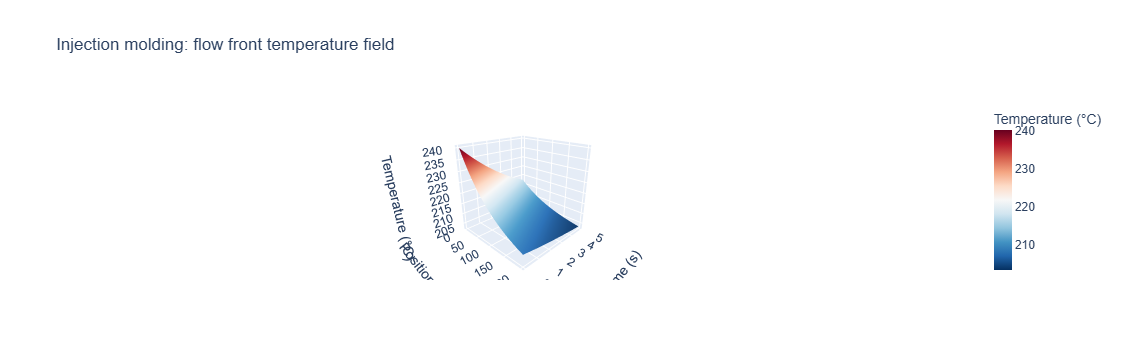

In [13]:
fig_surf = go.Figure(data=go.Surface(
    x=X_grid,
    y=T_grid,
    z=temp_field,
    colorscale='RdBu_r',
    colorbar=dict(title='Temperature (°C)', thickness=18),
    hovertemplate=(
        'Position: %{x:.1f} mm<br>'
        'Fill time: %{y:.2f} s<br>'
        'Temperature: %{z:.1f} °C'
        '<extra></extra>'
    )
))

fig_surf.update_layout(
    title='Injection molding: flow front temperature field',
    scene=dict(
        xaxis_title='Position (mm)',
        yaxis_title='Fill time (s)',
        zaxis_title='Temperature (°C)',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9))
    ),
    font_family='Arial'
)

fig_surf.show()

The `scene.camera` setting in `update_layout` sets an initial viewing angle, equivalent to Matplotlib's `view_init`. Hover over any point on the surface to read the exact temperature at that combination of position and fill time. Drag to rotate, scroll to zoom. The interactivity is particularly useful for surfaces with complex geometry: you can inspect any corner of the surface without re-rendering.

## 7. Exporting to a standalone HTML file

`fig.write_html()` saves a complete interactive figure as a single `.html` file. The file is self-contained: it embeds the Plotly JavaScript library and all the figure data, so anyone with a browser can open it and interact with the plot with no Python installation required. This makes HTML export the most practical way to share interactive figures with collaborators who do not use Python.

In [14]:
# Save the TTS master curve as a standalone interactive HTML file
output_path = './result/tts_master_curve.html'
fig_tts.write_html(output_path)

print(f'Saved: {output_path}')
print('Open this file in any browser to get the full interactive figure.')
print('No Python, no Jupyter, no dependencies required.')

Saved: ./result/tts_master_curve.html
Open this file in any browser to get the full interactive figure.
No Python, no Jupyter, no dependencies required.


The saved file will appear in the Colab file panel (the folder icon in the left sidebar). Right-click and download it to your local machine. The default file size for a figure with embedded Plotly JS is around 3 to 5 MB; you can reduce this by passing `include_plotlyjs='cdn'` to `write_html`, which links to a hosted copy of the library instead of embedding it. That option requires an internet connection to view the file.

## 8. Exporting to a static image with `fig.write_image()`

When you need a static PNG, SVG, or PDF from a Plotly figure (for a journal submission or a slide deck), `fig.write_image()` handles the conversion. It requires the `kaleido` package, which Plotly uses as its rendering backend for static export.

In [15]:
#!pip install kaleido --quiet

In [16]:
# write_image infers the format from the file extension
fig_scatter.write_image('./result/polymer_scatter.png', width=900, height=600, scale=2)
fig_scatter.write_image('./resultpolymer_scatter.svg')

print('Exported polymer_scatter.png (raster, 2x scale for retina displays)')
print('Exported polymer_scatter.svg (vector, resolution-independent)')

Exported polymer_scatter.png (raster, 2x scale for retina displays)
Exported polymer_scatter.svg (vector, resolution-independent)


The `scale` argument multiplies the pixel dimensions without changing the figure layout, which is useful for producing print-resolution rasters from a screen-resolution figure definition. SVG export produces a vector file that can be opened in Inkscape or Illustrator for final adjustments before submission. For most journals, a 300 DPI PNG (`scale=3` at 900 px wide gives approximately 300 DPI at a 3-inch column width) or a PDF is the expected format.